In [1]:
with open("/kaggle/input/datasets/sara2graca/victorian-poetry/corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

In [2]:
# character tokenizer

chars = sorted(list(set(corpus)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

In [3]:
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

Vocabulary size: 201
Characters: 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_abcdefghijklmnopqrstuvwxyz{|}~£·ÀÁÄÆÇÈÉËÍÒÖÚàáâäæçèéêëíîïñòóôöùúûüÿĩŒœΑΕΠΣΤΦΧάέήίαβγδεζηθικλμνξοπρςστυφχωόύώἀἄἅἐἔἥὀὁὍὐὑὗὰὲὴὶὸῖῦῶ–—‘’“”•™


In [4]:
import torch
import torch.nn as nn

# the transformer block with a triangular causal mask, no flash attention

class TransformerBlockManual(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        normed = self.ln1(x)
        x = x + self.drop(
            self.attn(normed, normed, normed, attn_mask=mask)[0])
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        normed = self.ln1(x)

        q = self.W_q(normed)
        k = self.W_k(normed)
        v = self.W_v(normed)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        attn = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, dropout_p=self.drop.p, is_causal=True)

        attn = attn.transpose(1, 2).contiguous().view(B, T, C)
        attn = self.W_o(attn)

        x = x + self.drop(attn)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [6]:
def make_causal_mask(seq_len, device):
    # matrix where future positions are masked out
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

In [7]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, context_len, dropout=0.1, use_flash=True):
        super().__init__()
        self.use_flash = use_flash
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop = nn.Dropout(dropout)

        block_class = TransformerBlock if use_flash else TransformerBlockManual
        self.blocks = nn.ModuleList([
            block_class(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        x = self.drop(self.token_emb(x) + self.pos_emb(positions))

        if self.use_flash:
            for block in self.blocks:
                x = block(x)
        else:
            mask = make_causal_mask(seq_len, x.device)
            for block in self.blocks:
                x = block(x, mask=mask)

        x = self.ln_final(x)
        return self.head(x)

In [8]:
context_len = 512

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPT(vocab_size, 256, 8, 6, 1024, context_len).to(device)  # with flash attention

In [10]:
# encode the entire corpus
data = torch.tensor([char_to_idx[c] for c in corpus], dtype=torch.long)

# train/validation split (90/10)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train tokens: {len(train_data)}")
print(f"Val tokens: {len(val_data)}")

Train tokens: 4882914
Val tokens: 542546


In [11]:
def get_batch(data, batch_size, context_len, device):
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([data[i:i+context_len] for i in ix])
    y = torch.stack([data[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)

In [12]:
from google.colab import files

def generate(model, prompt, max_new_chars, device, temperature=1.0):
    model.eval()

    x = torch.tensor([char_to_idx[c] for c in prompt], dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_chars):

            x_crop = x[:, -context_len:]
            logits = model(x_crop)

            logits = logits[:, -1, :] / temperature
            probs = torch.nn.functional.softmax(logits, dim=-1)
            next_char = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_char], dim=1)

    return ''.join([idx_to_char[i.item()] for i in x[0]])

In [13]:
from tqdm.notebook import tqdm
from google.colab import files

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
    lambda step: min(1.0, (step + 1) / 1000))

loss_fn = nn.CrossEntropyLoss()
n_steps = 20_000

train_losses = []
val_losses = []

for step in tqdm(range(1, n_steps + 1)):
    model.train()
    x_train, y_train = get_batch(train_data, 64, context_len, device)

    logits = model(x_train)
    loss = loss_fn(logits.view(-1, vocab_size), y_train.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % 250 == 0:
        model.eval()
        train_loss_avg = 0
        val_loss = 0
        with torch.no_grad():
            for _ in range(5):
                x_train_eval, y_train_eval = get_batch(train_data, 64, context_len, device)
                train_logits = model(x_train_eval)
                train_loss_avg += loss_fn(
                    train_logits.view(-1, vocab_size),
                    y_train_eval.view(-1)
                ).item()

                x_val, y_val = get_batch(val_data, 64, context_len, device)
                val_logits = model(x_val)
                val_loss += loss_fn(
                    val_logits.view(-1, vocab_size),
                    y_val.view(-1)
                ).item()

        train_loss_avg /= 5
        val_loss /= 5
        val_bpc = val_loss / 0.6931

        tqdm.write(f"step {step} | train loss {train_loss_avg:.4f} | val loss {val_loss:.4f} | val bpc {val_bpc:.4f}")
        train_losses.append(train_loss_avg)
        val_losses.append(val_loss)

    if step % 2000 == 0:
        sample = generate(model, prompt="There was a Boy whose name was Jim;\n", max_new_chars=500, device=device)
        tqdm.write(f"\n{sample}\n")
        checkpoint_path = f'/kaggle/working/checkpoint_step{step}.pt'
        torch.save({
            'step': step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, checkpoint_path)

  0%|          | 0/20000 [00:00<?, ?it/s]

step 250 | train loss 2.7360 | val loss 2.7220 | val bpc 3.9273
step 500 | train loss 2.5040 | val loss 2.5132 | val bpc 3.6260
step 750 | train loss 2.4107 | val loss 2.3607 | val bpc 3.4060
step 1000 | train loss 2.2412 | val loss 2.2660 | val bpc 3.2693
step 1250 | train loss 2.1680 | val loss 2.1559 | val bpc 3.1106
step 1500 | train loss 2.0092 | val loss 2.0237 | val bpc 2.9197
step 1750 | train loss 1.9656 | val loss 1.9742 | val bpc 2.8484
step 2000 | train loss 1.8969 | val loss 1.8834 | val bpc 2.7174

There was a Boy whose name was Jim;
  “Heaquacopr a upour prayse me."
       _Fry deletes_;
   To with lating? Fairy, ellong thear ginlar’?”-
        In the eyove wean lovine.

                                               _Herady_




          "For IN SWamph J. I.
   Dilky Grace,” I dong, my down.'t Gowd TeKawes liky               "Meh,
                _Forkrnown_" ald Bearmathy VAg.

   I


An' set aquobem Dill a Pa"stinglybons! "Comening!
     _Chou_ 'Add.



   [O'l he an

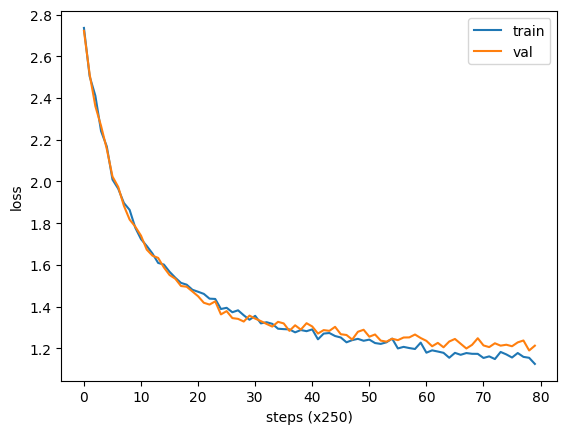

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.xlabel('steps (x250)')
plt.ylabel('loss')
plt.show()